In [34]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns

# Problem Set 4
## Monte Carlo Eksperimenter

I ugeseddel 4 skal I arbejde med et simulationsstudie, hvor I skal undersøge og sammenligne en simpel og multipel OLS estimator i et tilfælde med udeladt variabelbias. Generelt kan I bruge Monte Carlo eksperimenter til at opstille en model, hvor I kan kontrollere alle aspekter af den, undersøge egenskaber ved en estimator, f.eks. hvis MLR.1 til MLR.4 ikke er opfyldt, eller hvis I ønsker at undersøge en ny estimator eller undersøge asymptotiske resultater.

I denne ugeseddel skal I se nærmere på følgende datagenererende proces (DGP): 

\begin{align}
y_i &= \beta_0 + \beta_1 x_{1i} +\beta_2 x_{2i}+ u_i, \\
\beta_0 &= 1,\, \beta_1 = 2, \beta_2=-3, \\
x_1 &\sim N(25,25),\, u\sim U(-50,50), \, \, x_2^*\sim U(10,30) \\
x_2 &= \rho x_1 + x_2^*, \, \rho=0.5, \, n=50
\end{align}

Den datagenerende proces specificerer de sande værdier af $\beta_0$, $\beta_1$ og $\beta_2$ samt fordelingerne af $x_1$, $x_2$ og $u$. I dette tilfælde viser ligning (2) de sande parameterværdier, ligning (3) viser hvilken fordeling $x_1$, $x_2^*$ og $u$ er trukket fra, og ligning (1) viser sammenhængen imellem dem i en lineær regression. Ligning (4) viser, at $x_2$ er en lineær funktion af de stokastiske variable $x_1$ og $x_2^*$, hvor $\rho$ angiver hvor meget $x_2$ afhænger af $x_1$.

I skal undersøge og sammenligne egenskaberne for OLS estimatoren i en simpel og multipel regressionsmodel. Nedenfor er udtrykket for OLS estimatoren for $\beta_1$ i det simple tilfælde, $\widetilde{\beta}_1$, og i et tilfælde med flere forklarende variable, $\widehat{\beta}_1$.

\begin{align} \tag{5}
\widetilde{\beta }_{1}& =\frac{\sum_{i}(x_{i1}-\bar{x}_{1})(y_{i}-\bar{y})}{%
\sum_{i}(x_{i1}-\bar{x}_{1})^{2}} \\[8pt]
\widehat{\beta }& =\left( 
\begin{array}{c} \tag{6}
\widehat{\beta }_{0} \\ 
\widehat{\beta }_{1} \\ 
\widehat{\beta }_{2}%
\end{array}%
\right) =(X^{\prime }X)^{-1}X^{\prime }y
\end{align}%
hvor $X$ i ligning (6) indeholder information om $x_{1}$, $x_{2}$ og en konstant. 


## Gruppespørgsmål

**Opgave 1:** Forventer I en positiv eller negativ bias, når I estimerer en simpel model kun med $x_1$? Hvad er størrelsen på den asymptotiske bias? Beregn dette (brug pen og papir).

[Anvend følgende udtryk for asymptotisk bias, hvor $\widetilde{u}=\beta_2x_2 + u$]
\begin{align*}
p\text{lim}(\widetilde{\beta}_1)-\beta_1 = \frac{\text{Cov}(x_1,\widetilde{u})}{%
\text{Var}(x_1)}
\end{align*}


**Dit svar:**

Negativ bias

**Opgave 2:** Opfylder den datagenererende proces MLR.1 til MLR.4? 

**Dit svar:**

Den er lineær i parametrene - MLR. 1\\
der er random sampling MLR. 2\\
Der er ikke perfekt multikulinaritet så længe $x_2^*\neq 0$ \\
$E(u|x)=0$ Zero conditional mean. u er helt uafhængig af x.


**Opgave 3:** Hvordan kan et Monte Carlo-eksperiment blive brugt til at sammenligne variansen fra to forskellige middelrette estimatorer?

**Dit svar:**

Så man kan sammenligne varians og dermed vurdere hvilken en som er bedst/efficient.

## Python øvelser

### Opgave 1

I skal starte med at opstille Monte Carlo eksperimentet i Python. I skal udfylde den del af Python-koden, som mangler. I skal først køre Monte Carlo eksperimentet, når I har skrevet al koden ind. Der skal udfyldes manglende kode i hvert af de fire steps angivet i kommentarerne til funktionen herunder.

In [35]:
def simulate(beta2, rho):
	## Step 1. Definer parameterværdier
	n = 50
	
	beta0 = 0
	beta1 = 2


	# Step 2. Simular data
	x1 = np.random.normal(loc=25, scale=5, size=n) # Trækker x1 fra normalfordeling
	u  = np.random.uniform(low=-50, high=50, size=n) # Trækker u fra uniformfordeling
	x2_star = np.random.uniform(low=10, high=30, size=n) # Trækker x2* fra uniformfordeling
	x2 = rho*x1 - x2_star
	y = beta0 + beta1*x1 + beta2*x2 + u

	## Step 3: Estimer SLR modellen (y ~ x1)
	X = pd.DataFrame({'x1': x1}) 
	X = sm.add_constant(X) 
	SLR_model   = sm.OLS(y,X)
	SLR_results = SLR_model.fit()
	beta1_SLR = SLR_results.params['x1'] # Gemmer beta1 fra SLR-estimatet

	# Step 4: Estimer MLR modellen (y ~ x1 + x2)
	X = pd.DataFrame({'x1': x1, 'x2': x2}) 
	X = sm.add_constant(X)
	MLR_model   = sm.OLS(y,X)
	MLR_results = MLR_model.fit()
	beta1_MLR = MLR_results.params['x1'] # Gemmer beta1 fra MLR-estimatet

	return beta1_SLR, beta1_MLR

In [36]:
### Denne funktion kører vores simulering 1000 gange og gemmer resultaterne i et DataFrame.
def monte_carlo(beta2,rho, reps=1000):
	np.random.seed(0) # Sæt seed så vi får samme tilfældige resultater hver gang
	SLR_results = [] # Liste til at gemme beta1 resultater fra SLR
	MLR_results = [] # Liste til at gemme beta1 resultater fra MLR

	for r in range(reps): # Kør simulationen "reps" antal gange
		beta1_MLR, beta1_SLR = simulate(beta2, rho)
		SLR_results.append(beta1_MLR)
		MLR_results.append(beta1_SLR)

	# Saml alle resultaterne i et pandas DataFrame
	results = pd.DataFrame({'beta1_SLR': SLR_results, 'beta1_MLR': MLR_results})

	return results

Kør simulationen og gem resultaterne:

In [37]:
results = monte_carlo(-3,0.5)
print(results)

     beta1_SLR  beta1_MLR
0     0.684332   2.279454
1     1.375844   4.143541
2     2.122651   3.000838
3     0.952236   2.305768
4     0.725216   1.487166
..         ...        ...
995  -0.055820   0.949460
996   0.997850   1.467334
997   0.461481   2.602894
998   0.656434   1.919338
999   0.257068   1.390997

[1000 rows x 2 columns]


### Opgave 2 
Sammenlign $\widetilde{\beta}_1$ og $\widehat{\beta}_1$. Stemmer resultaterne overens med det, som I fandt i gruppespørgsmål 1? I kan bruge pandas metoden `.describe()` til at se gennemsnittet og variansen af $\widetilde{\beta}_1$ og $\widehat{\beta}_1$ fra eksperimentet.

**Din kode:**

In [38]:
print(results.describe())
results.var()


         beta1_SLR    beta1_MLR
count  1000.000000  1000.000000
mean      0.523873     2.031484
std       1.014884     0.952790
min      -3.266463    -0.945001
25%      -0.107784     1.427431
50%       0.539712     2.016547
75%       1.211343     2.677568
max       3.552006     4.483833


beta1_SLR    1.029990
beta1_MLR    0.907809
dtype: float64

**Dit svar:**

Ja der er negativ bias på 1.5, da den simple er 1.5 lavere.

### Opgave 3
Kør et Monte Carlo eksperiment med $n=10$ og $n=100$. Sammenlign $\widetilde{\beta}_1$ og $\widehat{\beta}_1$. Er både $\widetilde{\beta}_1$ og $\widehat{\beta}_1$ konsistente estimatorer for $\beta_1$?

**Dit svar:**

In [39]:
print(monte_carlo(-3, 0.5,10).describe())
monte_carlo(-3, 0.5,100).describe()

       beta1_SLR  beta1_MLR
count  10.000000  10.000000
mean    1.201101   2.606963
std     1.018140   1.028922
min    -0.792741   0.729328
25%     0.694553   2.286032
50%     1.164040   2.507421
75%     1.791288   3.207862
max     2.895414   4.143541


,beta1_SLR,beta1_MLR
count,100.000000,100.000000
mean,0.505336,2.044283
std,1.006934,0.952411
min,-2.012814,-0.162437
25%,-0.202526,1.428018
50%,0.562088,1.985799
75%,1.214423,2.688028
max,2.895414,4.157083


Beta SLR er ikke konsistent, den nærmer ikke 2, som er den sande værdi. Dette skyldes bias.\\
MLR er konsistent da den nærmer sig 2, som er den sande værdi.

### Opgave 4
Kør er Monte Carlo eksperiment med $\rho=1$ og $\rho=0$ (og $n = 50$). Er multikolinearitet et problem, når $\rho = 1$? Bliver den asymptotiske bias større eller mindre? Hvis den gør, hvorfor er det tilfældet? Hvilken forskel er der i variansen af $\widetilde{\beta}_1$ og $\widehat{\beta}_1$, når $\rho = 0$? Hvilken estimator vil I foretrække?

**Dit svar:**

In [40]:
print(monte_carlo(-3, 1,50).describe())
print(monte_carlo(-3 , 0,50).describe())

       beta1_SLR  beta1_MLR
count  50.000000  50.000000
mean   -0.915826   2.050008
std     1.021859   1.109900
min    -3.512814  -0.173422
25%    -1.532779   1.306283
50%    -0.868395   1.868270
75%    -0.162030   2.596970
max     1.395414   4.513036
       beta1_SLR  beta1_MLR
count  50.000000  50.000000
mean    2.084174   2.025594
std     1.021859   0.913262
min    -0.512814  -0.151452
25%     1.467221   1.435178
50%     2.131605   2.148101
75%     2.837970   2.600867
max     4.395414   4.265203


### Opgave 5
Kør et Monte Carlo eksperiment med $\rho=0.5$ og $\beta_2=0$. Sammenlign $\widetilde{\beta}_1$ og $\widehat{\beta}_1$. Hvilken er estimator vil I foretrække i dette tilfælde?

**Dit svar:**

In [43]:
print(monte_carlo(0, 0.5).describe())

         beta1_SLR    beta1_MLR
count  1000.000000  1000.000000
mean      2.040564     2.031484
std       0.864880     0.952790
min      -0.841769    -0.945001
25%       1.455356     1.427431
50%       2.073008     2.016547
75%       2.627223     2.677568
max       4.594047     4.483833


### Opgave 6
Kør det oprindelige Monte Carlo eksperiment med et andet seed-nummer. I kan f.eks. sætte seed-nummeret til det år, I er født. Hvad kan I konkludere om $\widetilde{\beta}_1$ og $\widehat{\beta}_1$ ud fra denne ændring?

**Dit svar:**

### Ekstraopgave: 
Hvis I har mere tid tilbage, kan I lave histogrammer af  $\widetilde{\beta}_1$ og $\widehat{\beta}_1$  for hver ændring i Monte Carlo eksperimentet fra spørgsmål 2 til 6. I kan bruge koden nedenfor. Husk at gemme histogrammerne efter hver simulation, hvis I gerne vil sammenligne med det oprindelige eksperiment.

```py
import seaborn as sns
sns.histplot(results);
```

**Din kode:**

<Axes: ylabel='Count'>

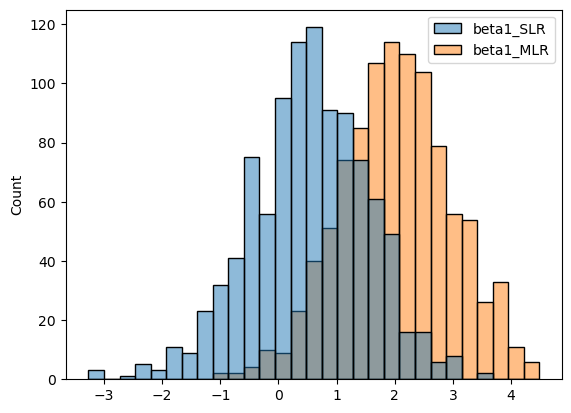

In [44]:
import seaborn as sns
sns.histplot(results)